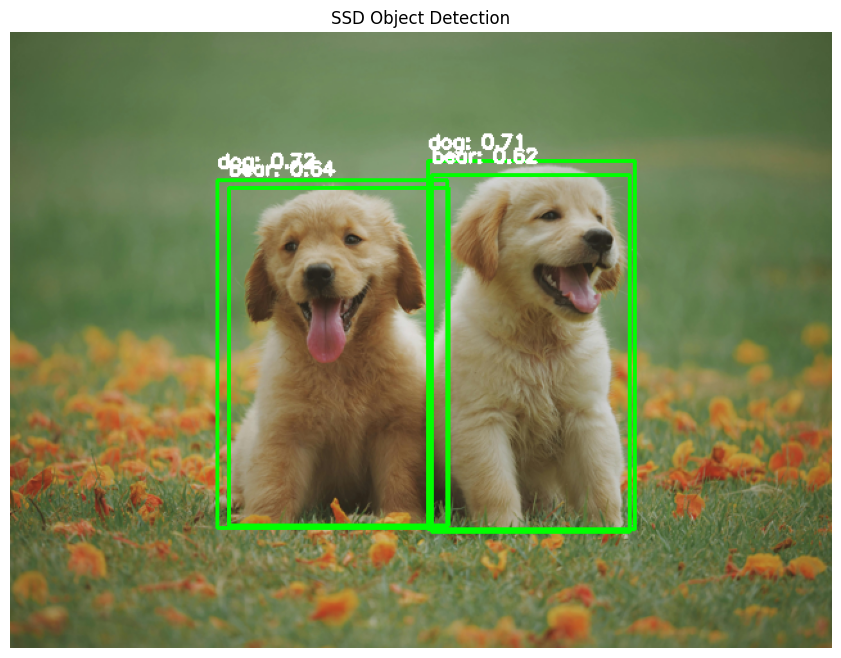

Detection Results:
Detection 1: dog (0.72)
Detection 2: dog (0.71)
Detection 3: bear (0.64)
Detection 4: bear (0.62)


In [6]:
# Step 1: Import libraries
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import urllib.request
from PIL import Image
import cv2

# Step 3: Load a sample image
image_path = "dogs.jpeg"  # Replace with your image

image = Image.open(image_path)
image_resized = image.resize((640, 480))  # SSD expects 640x480 for this model
image_np = np.array(image_resized).astype(np.uint8)

# Step 4: Load SSD model from TensorFlow Hub
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

# Step 5: Run inference
input_tensor = tf.convert_to_tensor([image_np], dtype=tf.uint8)
result = detector(input_tensor)

# Step 6: Display results
result = {key: value.numpy() for key, value in result.items()}

# Draw bounding boxes
def draw_boxes(image, boxes, class_ids, scores, class_names, score_threshold=0.3):
    img = np.array(image).copy()
    h, w, _ = img.shape

    # Extract the first batch (since we only have one image)
    boxes = boxes[0]  # Shape: (num_detections, 4)
    class_ids = class_ids[0]  # Shape: (num_detections,)
    scores = scores[0]  # Shape: (num_detections,)

    for box, cls, score in zip(boxes, class_ids, scores):
        score = float(score)
        cls = int(cls)
        if score < score_threshold:
            continue
        y_min, x_min, y_max, x_max = box
        (left, right, top, bottom) = (x_min * w, x_max * w, y_min * h, y_max * h)
        cv2.rectangle(img, (int(left), int(top)), (int(right), int(bottom)), (0, 255, 0), 2)
        label = f"{class_names[cls]}: {score:.2f}" if cls < len(class_names) else f"Class {cls}: {score:.2f}"
        cv2.putText(img, label, (int(left), int(top) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
    return img

# COCO label map (first 90 classes)
labels_path = tf.keras.utils.get_file(
    'mscoco_label_map.txt',
    'https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/data/mscoco_label_map.pbtxt'
)
# Quick workaround: use class IDs 1-90 from COCO
coco_labels = [
    "???", "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "???", "stop sign", "parking meter", "bench", "bird", "cat",
    "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "???", "backpack", "umbrella",
    "???", "???", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
    "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "???",
    "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant",
    "bed", "???", "dining table", "???", "???", "toilet", "???", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "???",
    "book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

# Show final image
output_image = draw_boxes(image_resized, result["detection_boxes"],
                          result["detection_classes"], result["detection_scores"],
                          coco_labels)

plt.figure(figsize=(12, 8))
plt.imshow(output_image)
plt.axis("off")
plt.title("SSD Object Detection")
plt.show()

# Optional: Print detection results
print("Detection Results:")
boxes = result["detection_boxes"][0]
class_ids = result["detection_classes"][0]
scores = result["detection_scores"][0]

for i, (box, cls, score) in enumerate(zip(boxes, class_ids, scores)):
    if float(score) > 0.3:  # Only show detections above threshold
        cls_name = coco_labels[int(cls)] if int(cls) < len(coco_labels) else f"Class {int(cls)}"
        print(f"Detection {i+1}: {cls_name} ({float(score):.2f})")